### Dados Utilizados:
Nascimentos e Mortes em Porto Alegre

SINASC - Sistema de Informações de Nascidos Vivos
> https://dadosabertos.poa.br/dataset/sinasc

SIM - Sistema de Informações de Mortalidade
> https://dadosabertos.poa.br/dataset/mortalidade-e-obitos

DataSUS - CID-10
> http://www2.datasus.gov.br/cid10/V2008/cid10.

### Problema inicial:
Analisar a base de dados de nascidos vivos, e mostrar:
- Nascimentos por mês/ano
- Nascimentos por Estado Civil da mãe
- Nascimentos por Idade da mãe
- Principais Ocupações das mães
- Distribuição por Sexo/Ano
- Número Média de Consultas Pré-Natais por Nascimento por Ano

Analisar a base de dados de mortes, e mostrar:
- Mortes por Subcategoria CID por Ano
- Mortes por Grupo CID por Mês/Ano
- Mortes por Tipo por Mês/Ano
- Homicídios por Mês/Ano

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

#criando categorias

df = pd.read_csv('sim_obitos.csv',delimiter=";")
df["obito"] = pd.to_datetime(df["obito"], format='%m/%Y')
df['sexo'] = df['sexo'].astype("category")
df['tipo_obito'] = df['tipo_obito'].astype("category")
df['cid_causa_basica'] = df['cid_causa_basica'].astype("category")

df['circunstancia_obito'] = df['circunstancia_obito'].astype(str).str.strip()

df['cid_grupo'] = df['cid_causa_basica'][:-1].astype("category")

df.info()
df.sample()

FileNotFoundError: [Errno 2] No such file or directory: 'sim_obitos.csv'

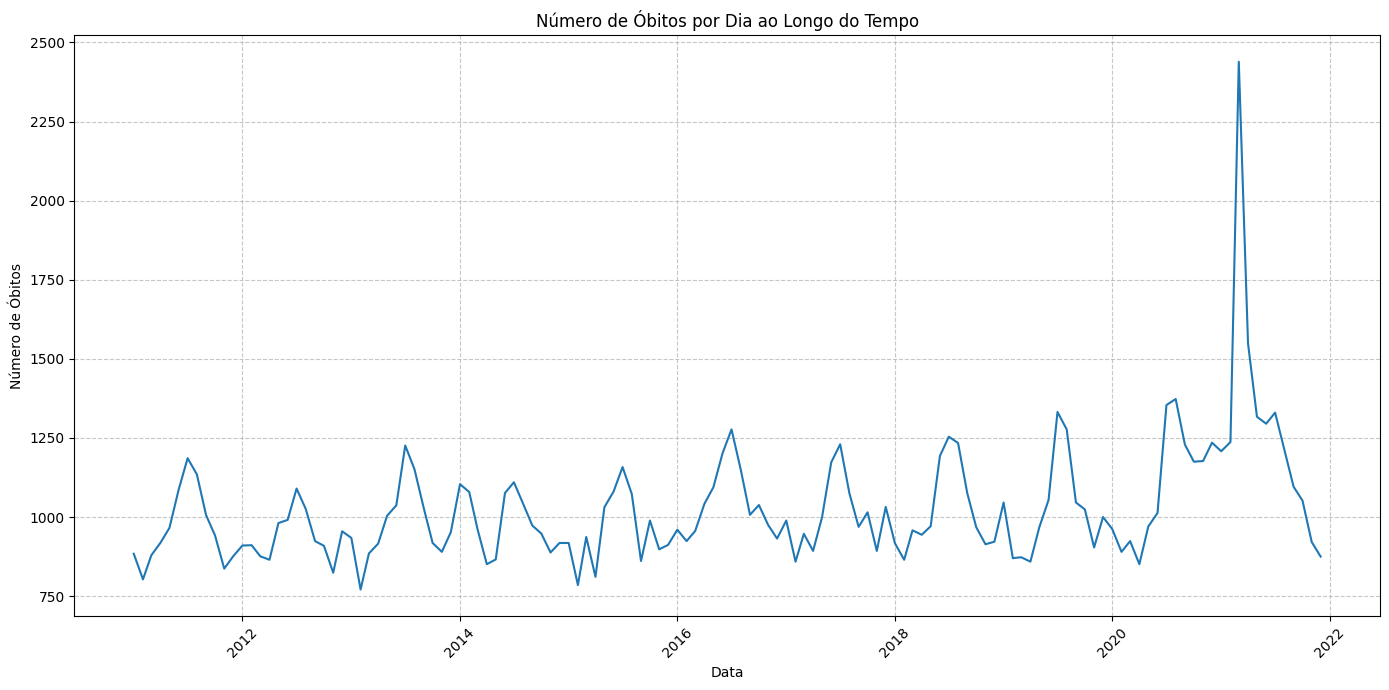

In [ ]:
mes = pd.DataFrame(df.groupby([df['obito'].dt.date])['obito'].count())
plt.figure(figsize=(14, 7)) # Define o tamanho da figura para melhor visualização
sns.lineplot(x=mes.index, y="obito", data=mes) # Usa o índice (data) no eixo X para a série temporal
plt.title('Número de Óbitos por Dia ao Longo do Tempo') # Adiciona um título descritivo
plt.xlabel('Data') # Rótulo para o eixo X
plt.ylabel('Número de Óbitos') # Rótulo para o eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade para facilitar a leitura
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para evitar sobreposição
plt.tight_layout() # Ajusta o layout para evitar cortes nos rótulos
plt.show() # Exibe o gráfico

### Vimos um problema?
O que aconteceu em Março de 2021?

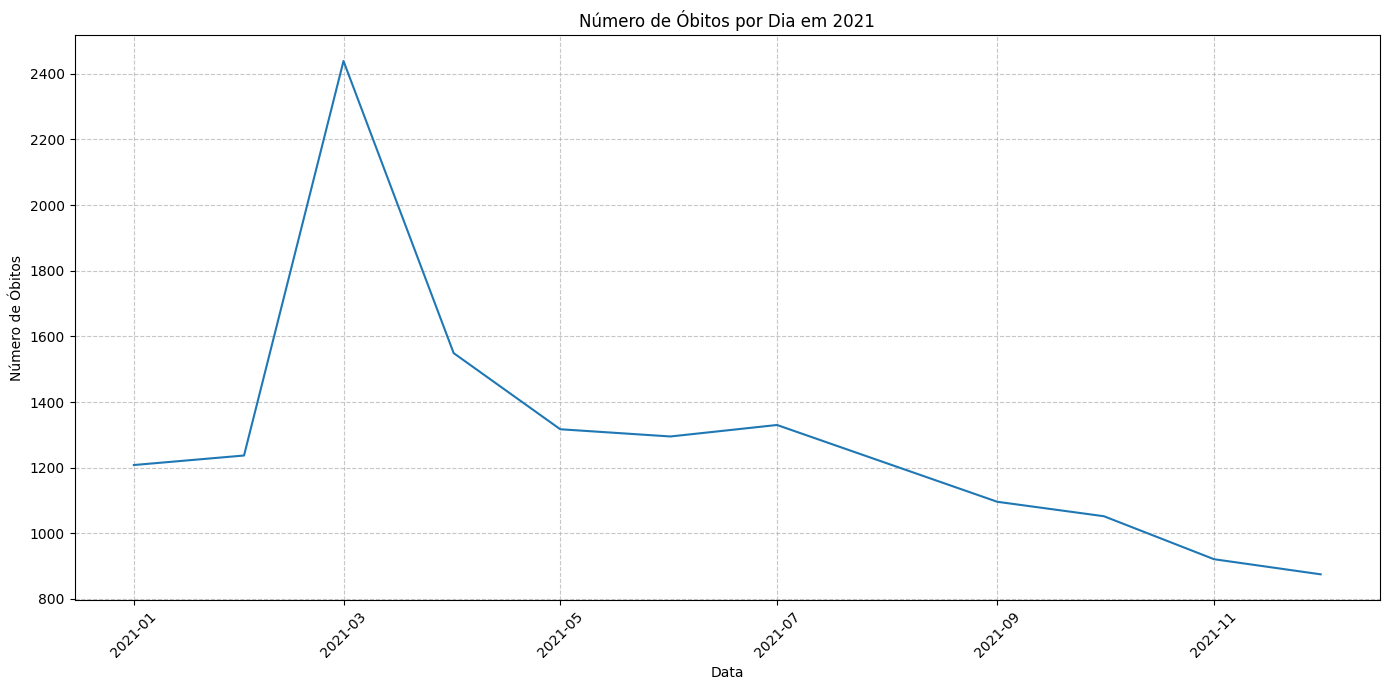

In [ ]:
mes = pd.DataFrame(df.groupby([df['obito'].dt.date])['obito'].count())
mes.index = pd.to_datetime(mes.index) # Convertendo o índice para DatetimeIndex
mes_2021 = mes[mes.index.year == 2021]

plt.figure(figsize=(14, 7))
sns.lineplot(x=mes_2021.index, y="obito", data=mes_2021)
plt.title('Número de Óbitos por Dia em 2021')
plt.xlabel('Data')
plt.ylabel('Número de Óbitos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

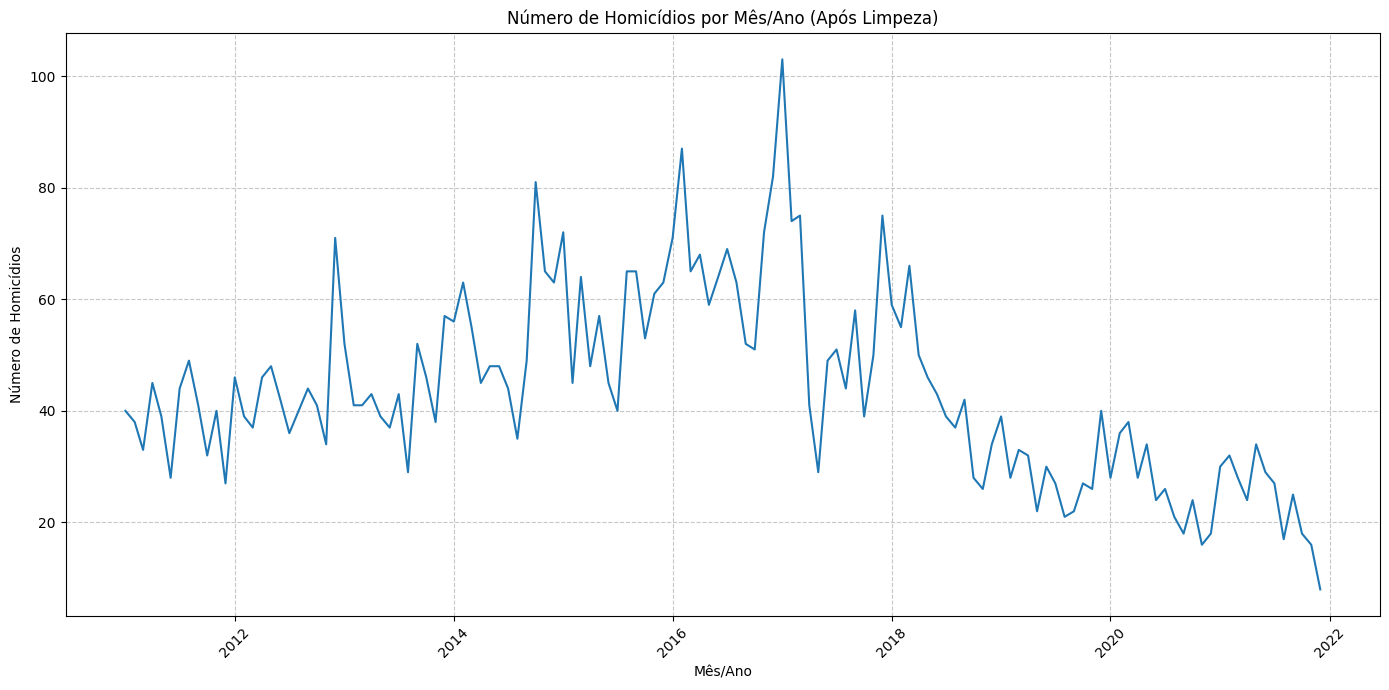

In [ ]:
# Filtrando o DataFrame para apenas homicídios (usando a coluna 'circunstancia_obito' limpa)
df_homicidios_limpo = df[df['circunstancia_obito'] == 'HOMICÍDIO']

# Agrupando por mês/ano e contando o número de homicídios
homicidios_mes_ano_limpo = df_homicidios_limpo.groupby([df_homicidios_limpo['obito'].dt.to_period('M')]).size().reset_index(name='Numero_Homicidios')
homicidios_mes_ano_limpo.columns = ['Mes_Ano', 'Numero_Homicidios']

# Convertendo a coluna 'Mes_Ano' para datetime para que o Seaborn possa plotar corretamente
homicidios_mes_ano_limpo['Mes_Ano'] = homicidios_mes_ano_limpo['Mes_Ano'].dt.to_timestamp()

# Plotando o número de homicídios por mês/ano
plt.figure(figsize=(14, 7))
sns.lineplot(x='Mes_Ano', y='Numero_Homicidios', data=homicidios_mes_ano_limpo)
plt.title('Número de Homicídios por Mês/Ano (Após Limpeza)')
plt.xlabel('Mês/Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

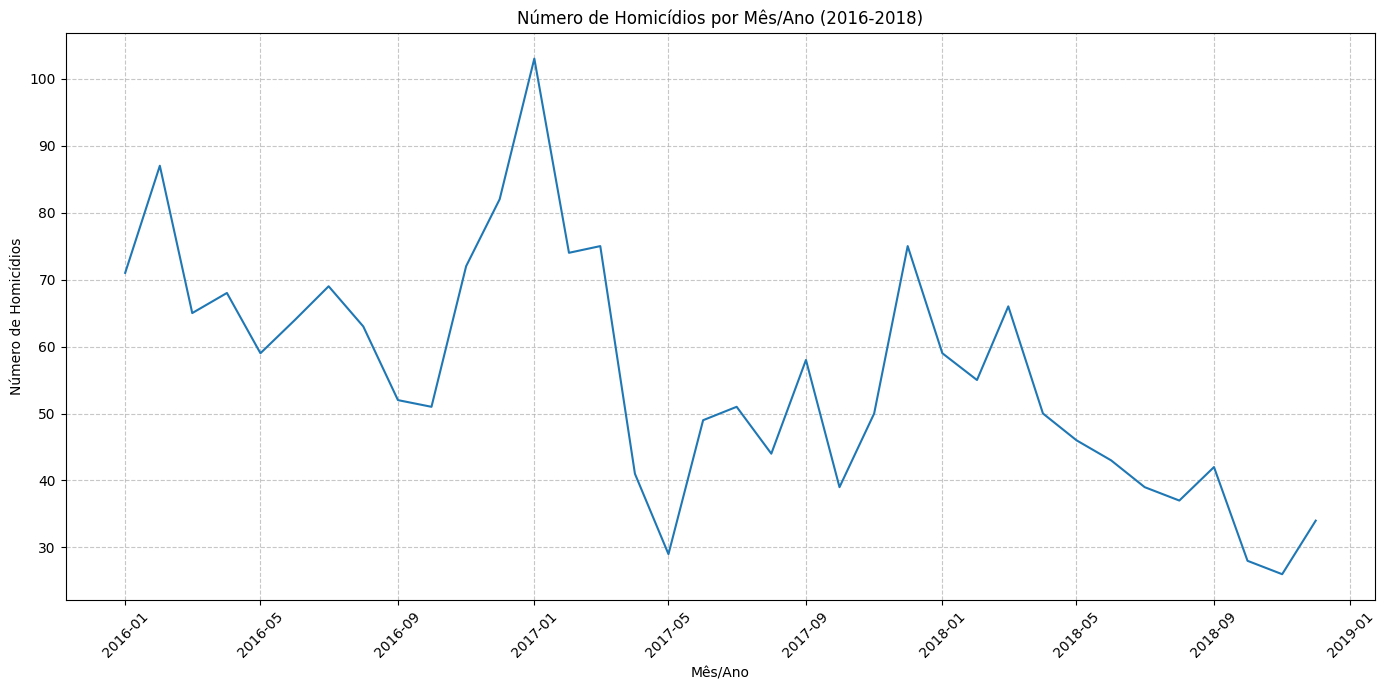

In [ ]:
homicidios_2016_2018 = homicidios_mes_ano_limpo[(homicidios_mes_ano_limpo['Mes_Ano'].dt.year >= 2016) & (homicidios_mes_ano_limpo['Mes_Ano'].dt.year <= 2018)]

plt.figure(figsize=(14, 7))
sns.lineplot(x='Mes_Ano', y='Numero_Homicidios', data=homicidios_2016_2018)
plt.title('Número de Homicídios por Mês/Ano (2016-2018)')
plt.xlabel('Mês/Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

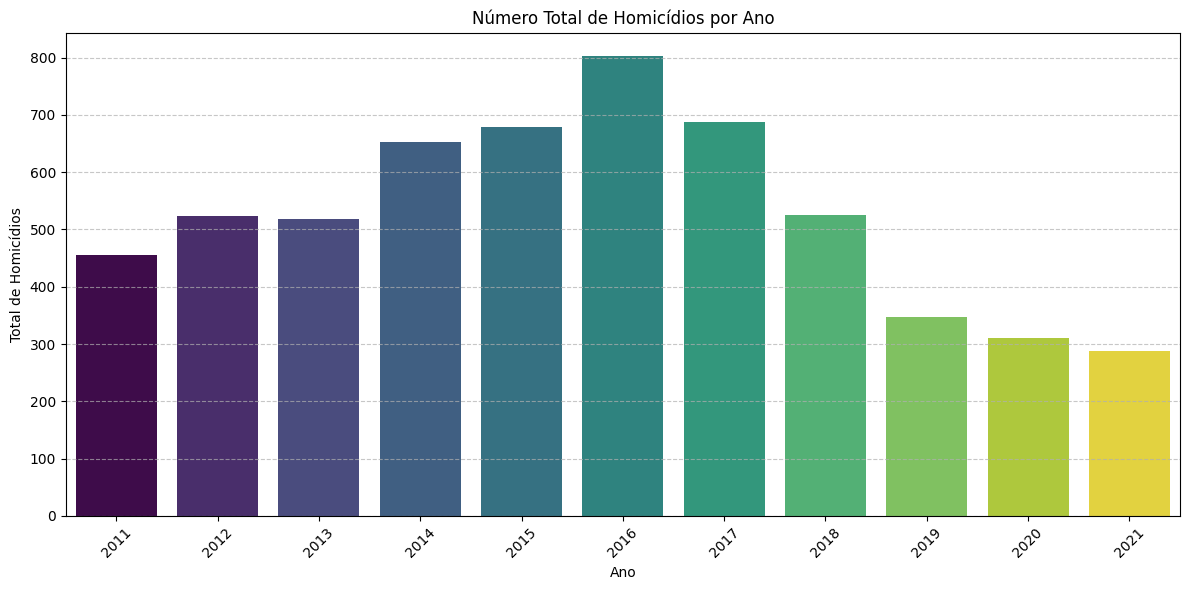

In [ ]:
homicidios_por_ano = homicidios_mes_ano_limpo.groupby(homicidios_mes_ano_limpo['Mes_Ano'].dt.year)['Numero_Homicidios'].sum().reset_index()
homicidios_por_ano.columns = ['Ano', 'Total_Homicidios']

plt.figure(figsize=(12, 6))
sns.barplot(x='Ano', y='Total_Homicidios', data=homicidios_por_ano, palette='viridis', hue='Ano', legend=False)
plt.title('Número Total de Homicídios por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Homicídios')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()